# 1. Data Collection & Loading

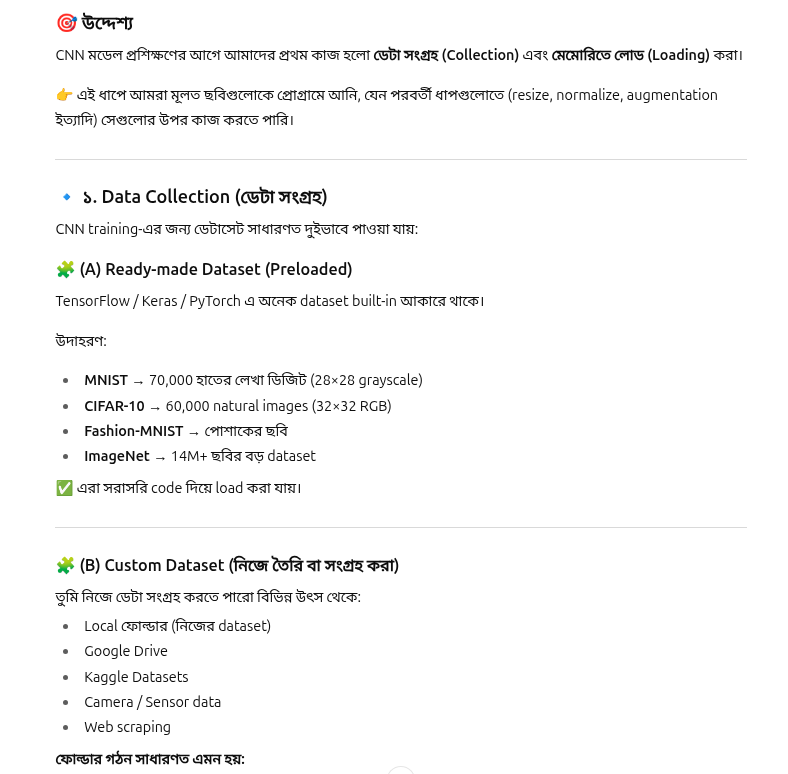

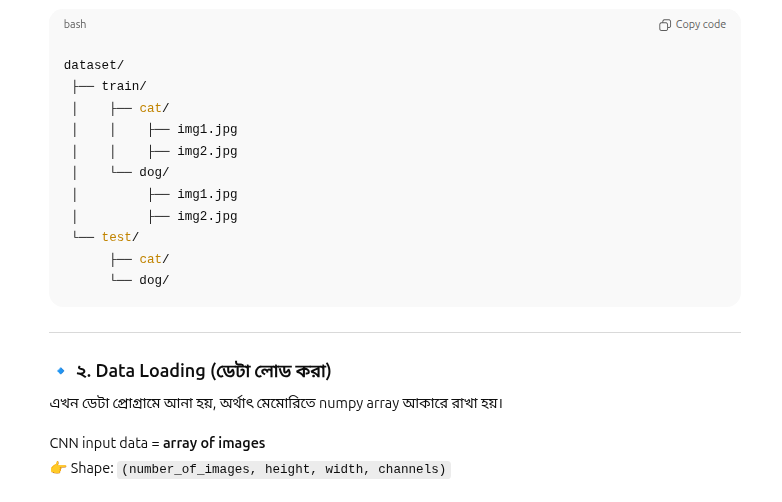

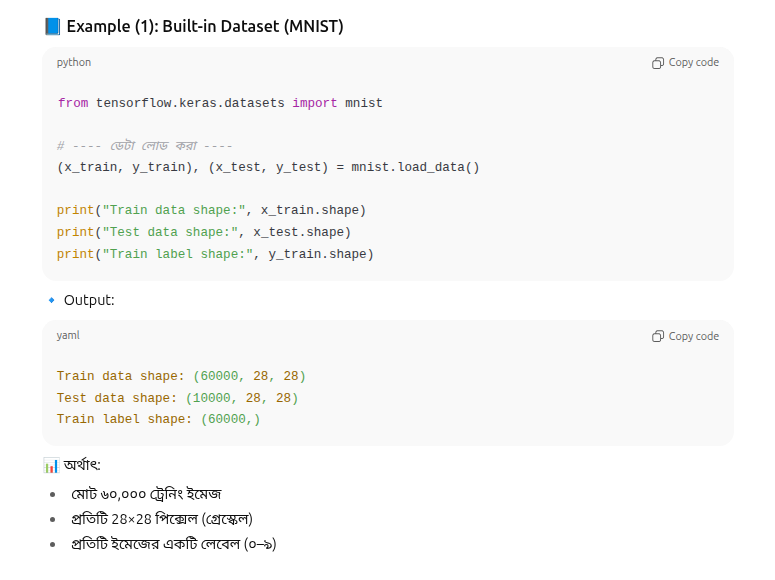

In [2]:
from tensorflow.keras.datasets import mnist

# ---- ডেটা লোড করা ----
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Train data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
print("Train label shape:", y_train.shape)

Train data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Train label shape: (60000,)


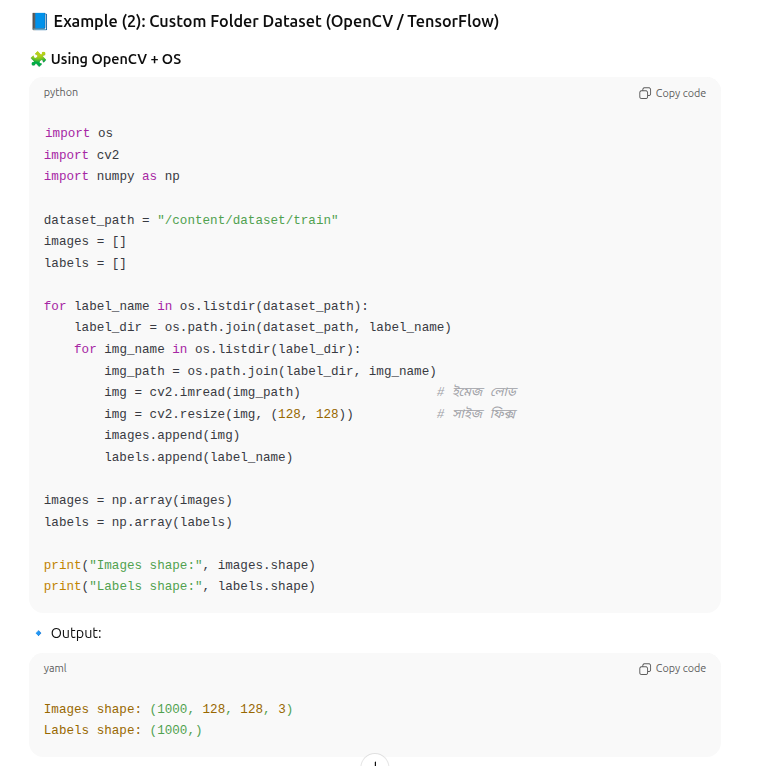

In [4]:
import os
import cv2
import numpy as np

dataset_path = "dataset/train"
images = []
labels = []

for label_name in os.listdir(dataset_path):
    label_dir = os.path.join(dataset_path, label_name)
    for img_name in os.listdir(label_dir):
        img_path = os.path.join(label_dir, img_name)
        img = cv2.imread(img_path)                  # ইমেজ লোড
        img = cv2.resize(img, (128, 128))           # সাইজ ফিক্স
        images.append(img)
        labels.append(label_name)

images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: (152, 128, 128, 3)
Labels shape: (152,)


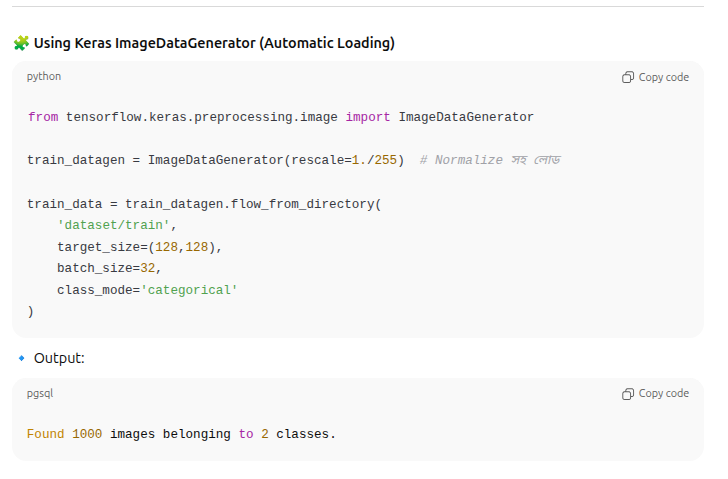

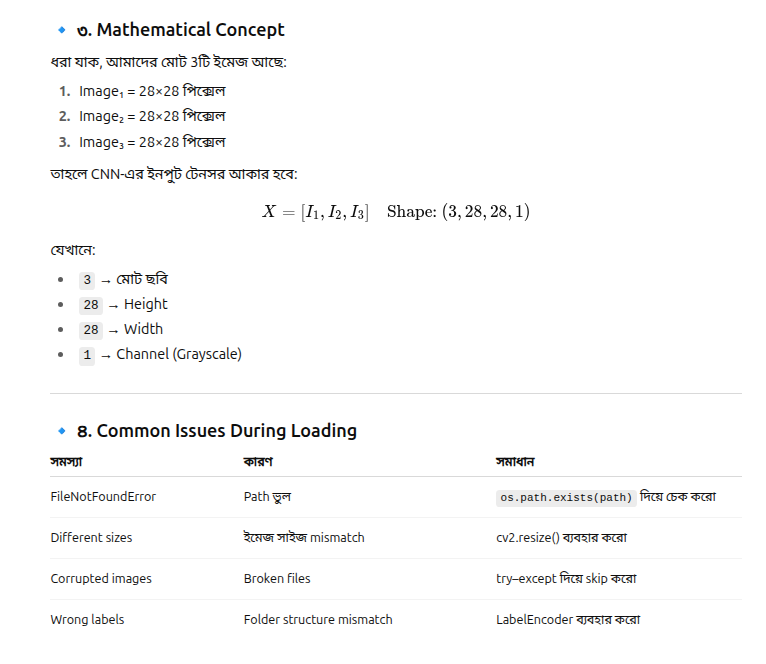

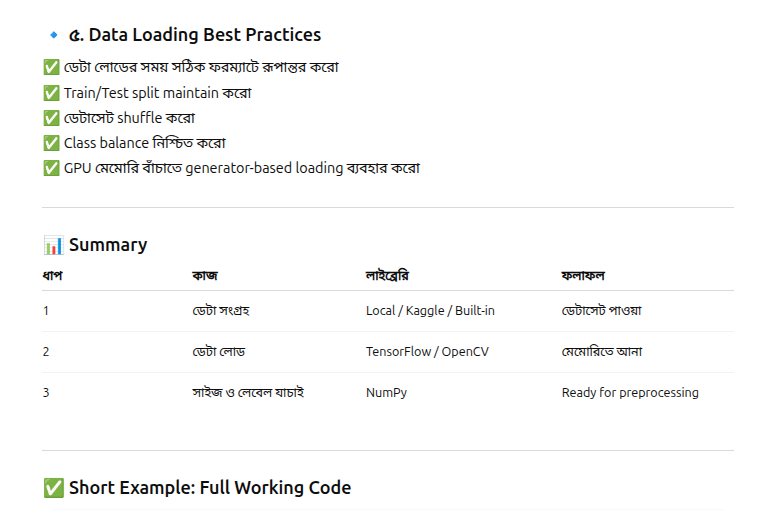

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


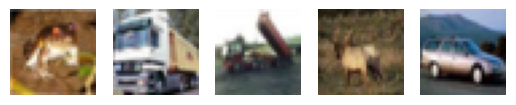

In [5]:
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

# Step 1: Load Data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

# Step 2: Visualize few samples
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i])
    plt.axis('off')
plt.show()

# 2. Step 2: Data Cleaning (ডেটা পরিষ্কার করা)

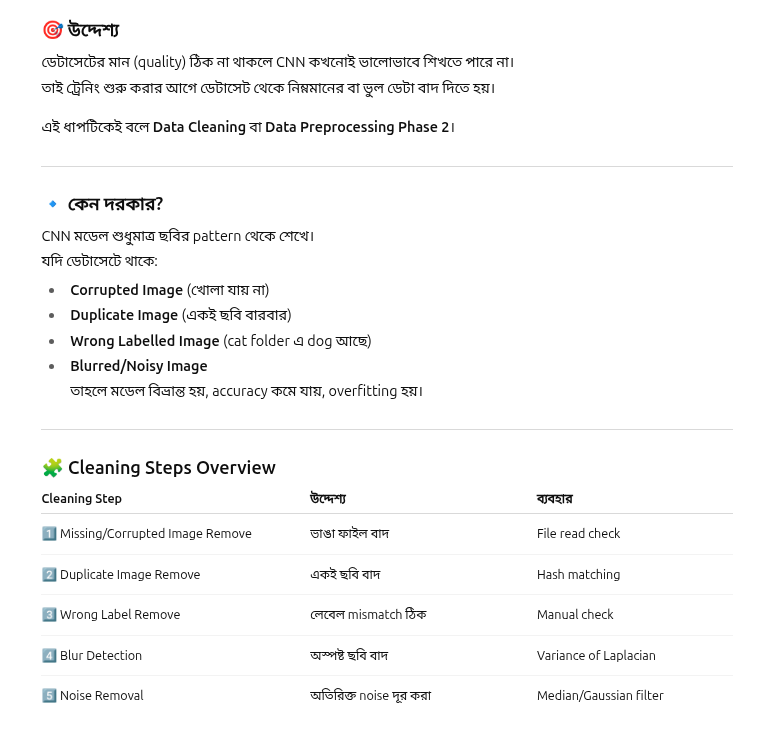

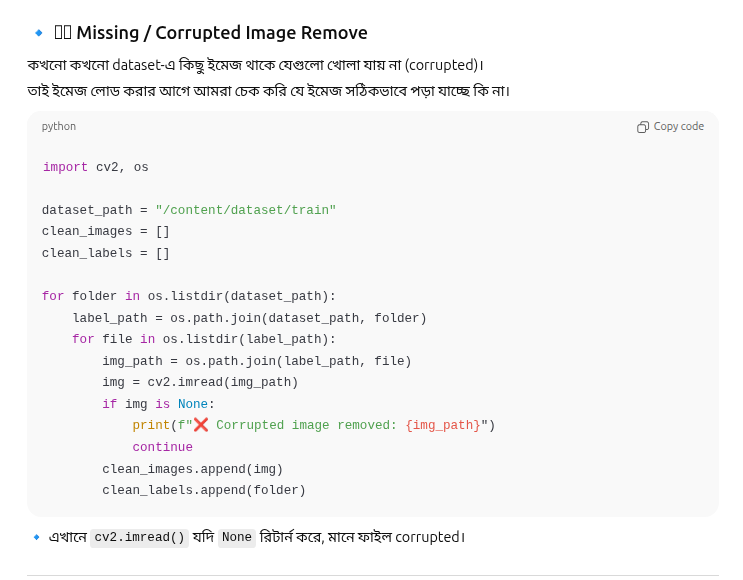

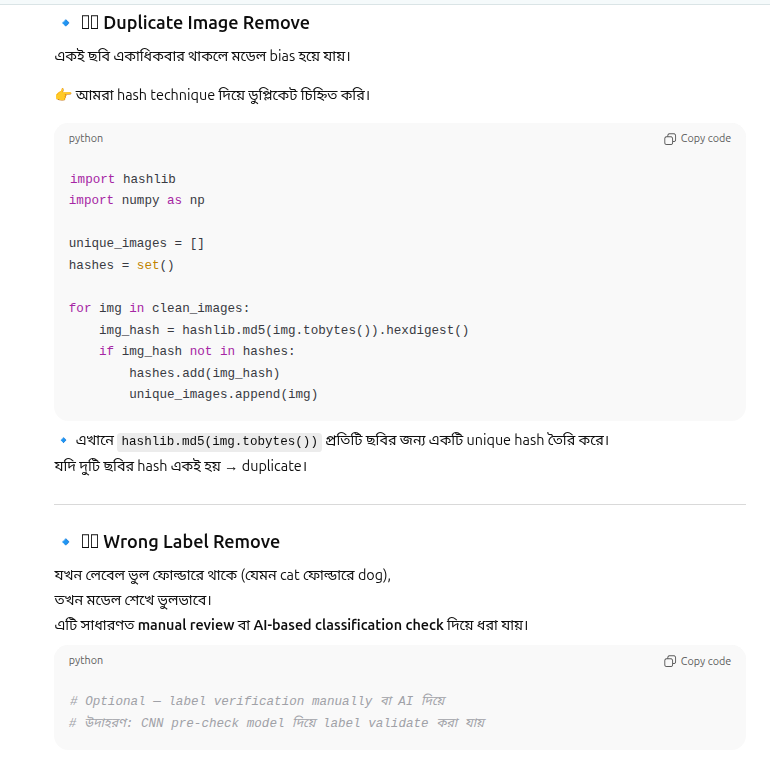

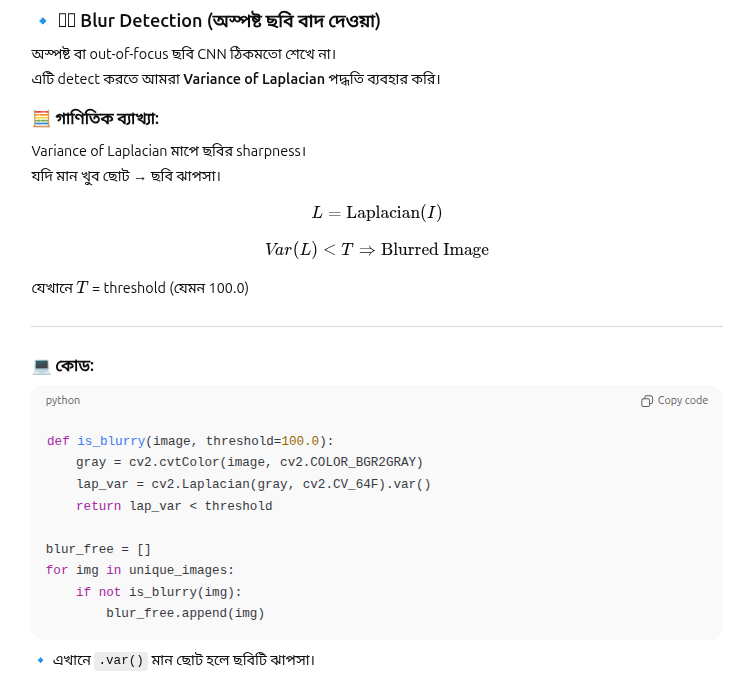

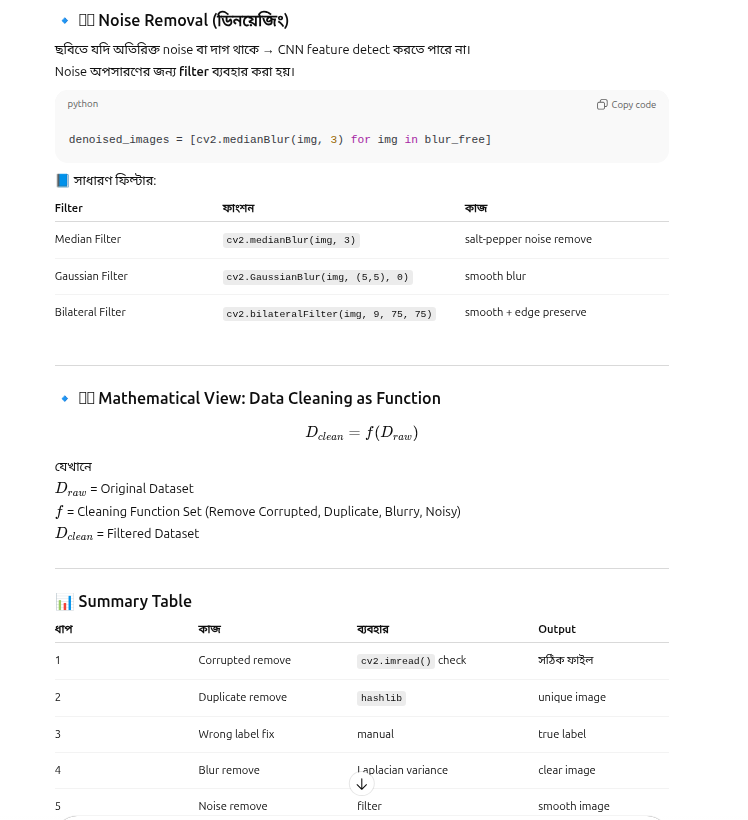

**✅ Full Cleaning Pipeline (One Script)**

In [8]:
import cv2, os, hashlib, numpy as np

def is_blurry(img, threshold=100.0):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var() < threshold

dataset_path = "dataset/train"
cleaned_data = []
cleaned_labels = []
hashes = set()

for label in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, label)
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        # Duplicate check
        h = hashlib.md5(img.tobytes()).hexdigest()
        if h in hashes:
            continue
        hashes.add(h)
        # Blur check
        if is_blurry(img):  
            continue
        # Denoise
        img = cv2.medianBlur(img, 3)
        cleaned_data.append(img)
        cleaned_labels.append(label)

print("✅ Cleaned dataset size:", len(cleaned_data))

✅ Cleaned dataset size: 137


In [9]:
import cv2, os, hashlib, numpy as np

def is_blurry(img, threshold=100.0):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var() < threshold

dataset_path = "dataset/train"
cleaned_data = []
cleaned_labels = []
hashes = set()

# Count total images before cleaning
total_images = 0
for label in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, label)
    for file in os.listdir(folder_path):
        total_images += 1

print("📌 Total images before cleaning:", total_images)

# Cleaning loop
for label in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, label)
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        # Duplicate check
        h = hashlib.md5(img.tobytes()).hexdigest()
        if h in hashes:
            continue
        hashes.add(h)
        # Blur check
        if is_blurry(img):  
            continue
        # Denoise
        img = cv2.medianBlur(img, 3)
        cleaned_data.append(img)
        cleaned_labels.append(label)

print("✅ Cleaned dataset size:", len(cleaned_data))
print("📌 Total removed images:", total_images - len(cleaned_data))

📌 Total images before cleaning: 152
✅ Cleaned dataset size: 137
📌 Total removed images: 15


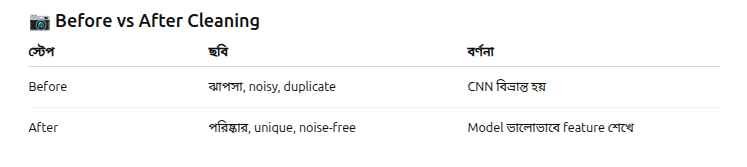

In [10]:
import cv2, os, hashlib, numpy as np

def is_blurry(img, threshold=100.0):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var() < threshold

dataset_path = "dataset/train"
cleaned_data = []
cleaned_labels = []
hashes = set()
removed_images = []  # List to store removed image names

# Count total images before cleaning
total_images = 0
for label in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, label)
    for file in os.listdir(folder_path):
        total_images += 1

print("📌 Total images before cleaning:", total_images)

# Cleaning loop
for label in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, label)
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)
        if img is None:
            removed_images.append(img_path + " (Failed to read)")
            continue
        # Duplicate check
        h = hashlib.md5(img.tobytes()).hexdigest()
        if h in hashes:
            removed_images.append(img_path + " (Duplicate)")
            continue
        hashes.add(h)
        # Blur check
        if is_blurry(img):  
            removed_images.append(img_path + " (Blurry)")
            continue
        # Denoise
        img = cv2.medianBlur(img, 3)
        cleaned_data.append(img)
        cleaned_labels.append(label)

print("✅ Cleaned dataset size:", len(cleaned_data))
print("📌 Total removed images:", total_images - len(cleaned_data))

# Print removed image names
print("\n❌ Removed Images:")
for img_name in removed_images:
    print(img_name)

📌 Total images before cleaning: 152
✅ Cleaned dataset size: 137
📌 Total removed images: 15

❌ Removed Images:
dataset/train/trent/1.webp (Blurry)
dataset/train/fernandes/5.webp (Blurry)
dataset/train/kohli/1.jpg (Blurry)
dataset/train/cancelo/1.jpeg (Blurry)
dataset/train/sinner/1.webp (Blurry)
dataset/train/sinner/2.jpg (Blurry)
dataset/train/messi/1.jpg (Blurry)
dataset/train/marcelo/1.jpg (Blurry)
dataset/train/marcelo/4.jpeg (Blurry)
dataset/train/casimiro/4.webp (Blurry)
dataset/train/shelton/1.jpg (Blurry)
dataset/train/mane/2.jpg (Blurry)
dataset/train/haaland/1.jpg (Blurry)
dataset/train/haaland/4.webp (Blurry)
dataset/train/cummins/1.jpg (Blurry)


# 3. Step 3: Data Reshape & Normalization (ডেটা রূপান্তর ও মান নির্ধারণ)

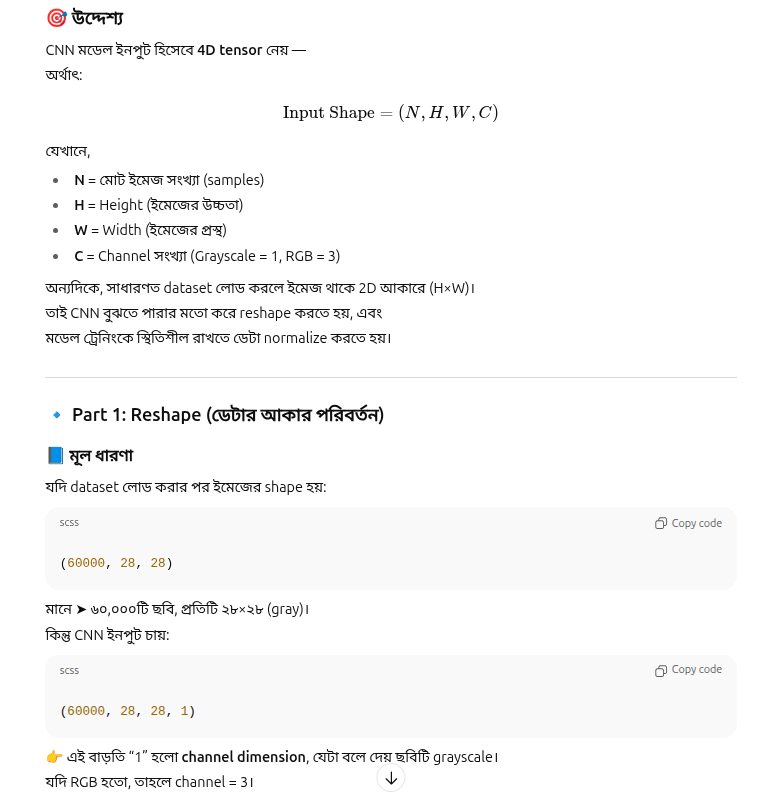

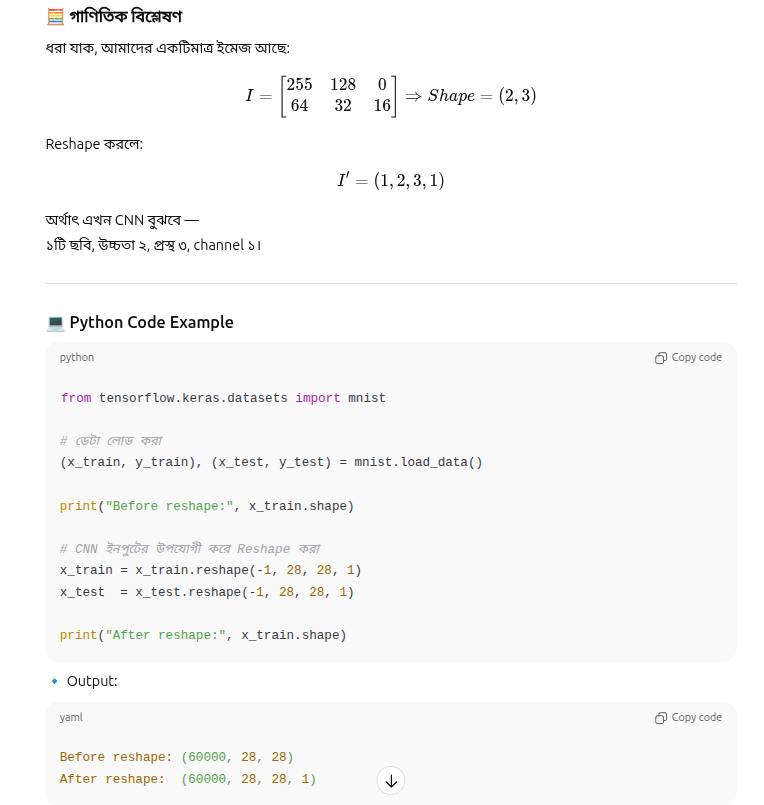

In [11]:
from tensorflow.keras.datasets import mnist

# ডেটা লোড করা
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Before reshape:", x_train.shape)

# CNN ইনপুটের উপযোগী করে Reshape করা
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

print("After reshape:", x_train.shape)

Before reshape: (60000, 28, 28)
After reshape: (60000, 28, 28, 1)


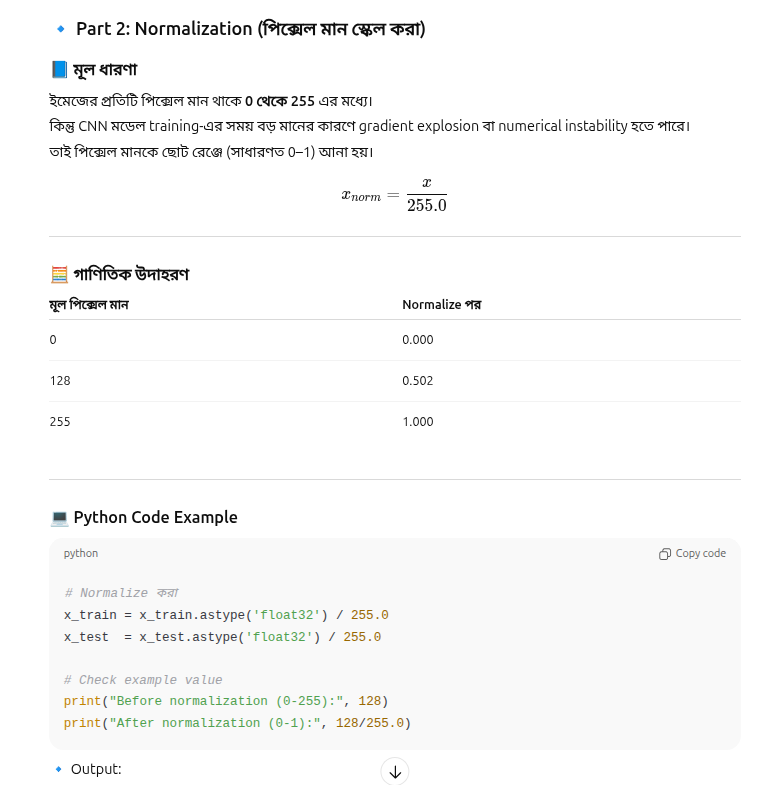

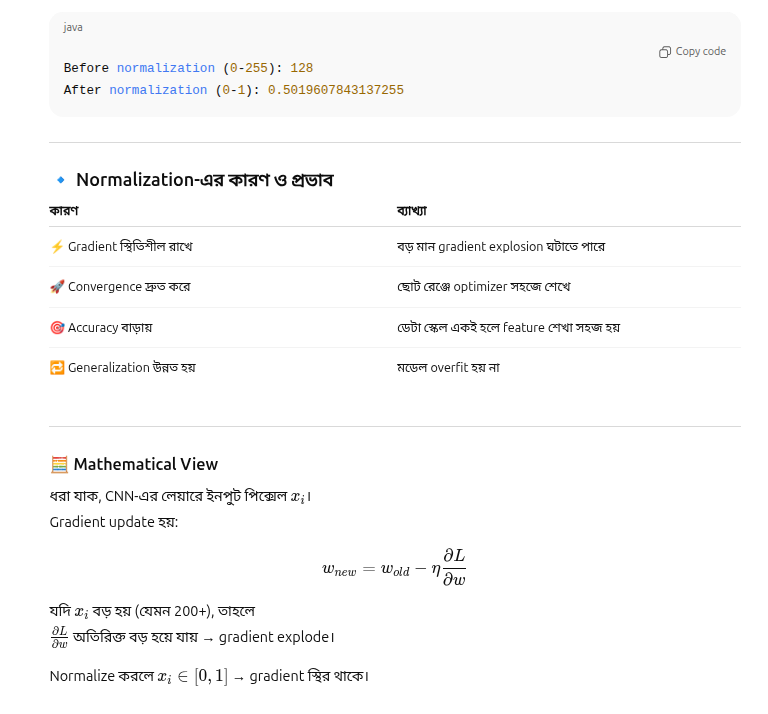

In [12]:
# Normalize করা
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

# Check example value
print("Before normalization (0-255):", 128)
print("After normalization (0-1):", 128/255.0)

Before normalization (0-255): 128
After normalization (0-1): 0.5019607843137255


**Combine Step: Reshape + Normalize একসাথে**

In [13]:
from tensorflow.keras.datasets import mnist
import numpy as np

# ডেটা লোড
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

# Normalize
x_train = x_train.astype(np.float32) / 255.0
x_test  = x_test.astype(np.float32) / 255.0

print("Train data:", x_train.shape, "Range:", (x_train.min(), x_train.max()))

Train data: (60000, 28, 28, 1) Range: (np.float32(0.0), np.float32(1.0))


**Visualization Example**

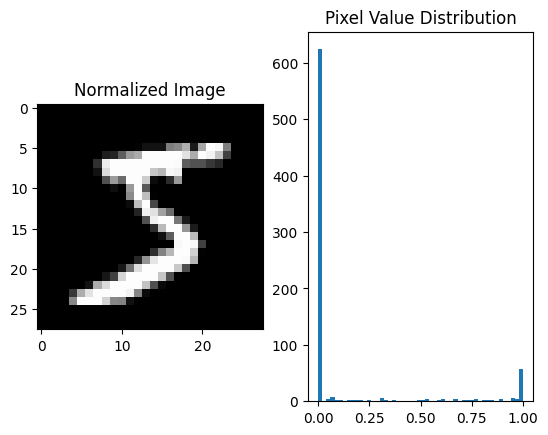

In [14]:
import matplotlib.pyplot as plt

plt.subplot(1,2,1)
plt.imshow(x_train[0].reshape(28,28), cmap='gray')
plt.title("Normalized Image")

plt.subplot(1,2,2)
plt.hist(x_train[0].ravel(), bins=50)
plt.title("Pixel Value Distribution")
plt.show()

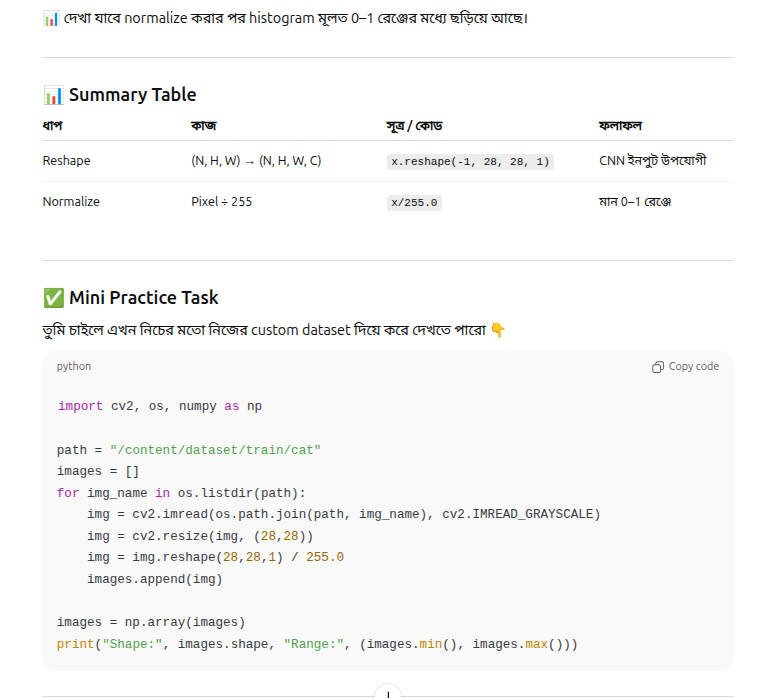

In [15]:
import cv2, os, numpy as np

path = "dataset/train/ronaldo/"
images = []
for img_name in os.listdir(path):
    img = cv2.imread(os.path.join(path, img_name), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (28,28))
    img = img.reshape(28,28,1) / 255.0
    images.append(img)

images = np.array(images)
print("Shape:", images.shape, "Range:", (images.min(), images.max()))

Shape: (6, 28, 28, 1) Range: (np.float64(0.0), np.float64(1.0))


# 4. Step 4: Label Encoding & One-Hot Encoding

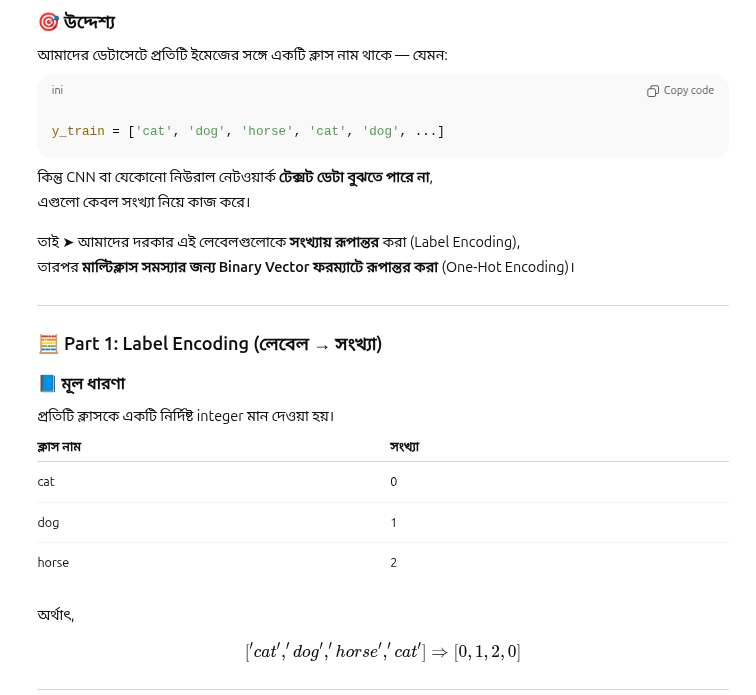

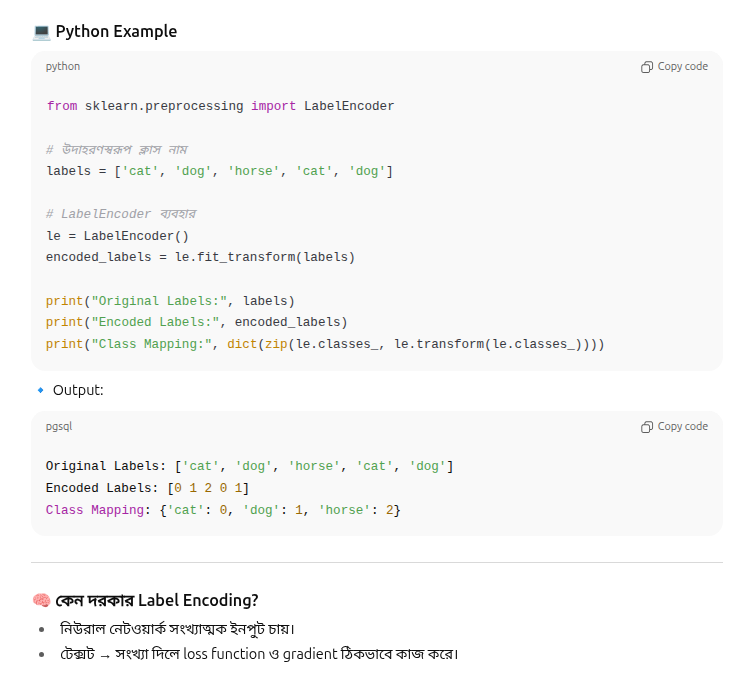

In [16]:
from sklearn.preprocessing import LabelEncoder

# উদাহরণস্বরূপ ক্লাস নাম
labels = ['cat', 'dog', 'horse', 'cat', 'dog']

# LabelEncoder ব্যবহার
le = LabelEncoder()
encoded_labels = le.fit_transform(labels)

print("Original Labels:", labels)
print("Encoded Labels:", encoded_labels)
print("Class Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Original Labels: ['cat', 'dog', 'horse', 'cat', 'dog']
Encoded Labels: [0 1 2 0 1]
Class Mapping: {np.str_('cat'): np.int64(0), np.str_('dog'): np.int64(1), np.str_('horse'): np.int64(2)}


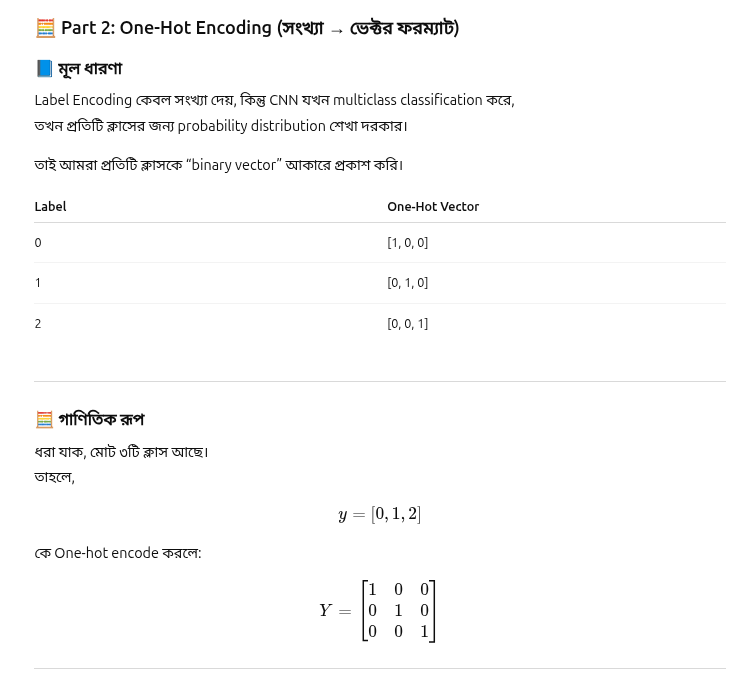

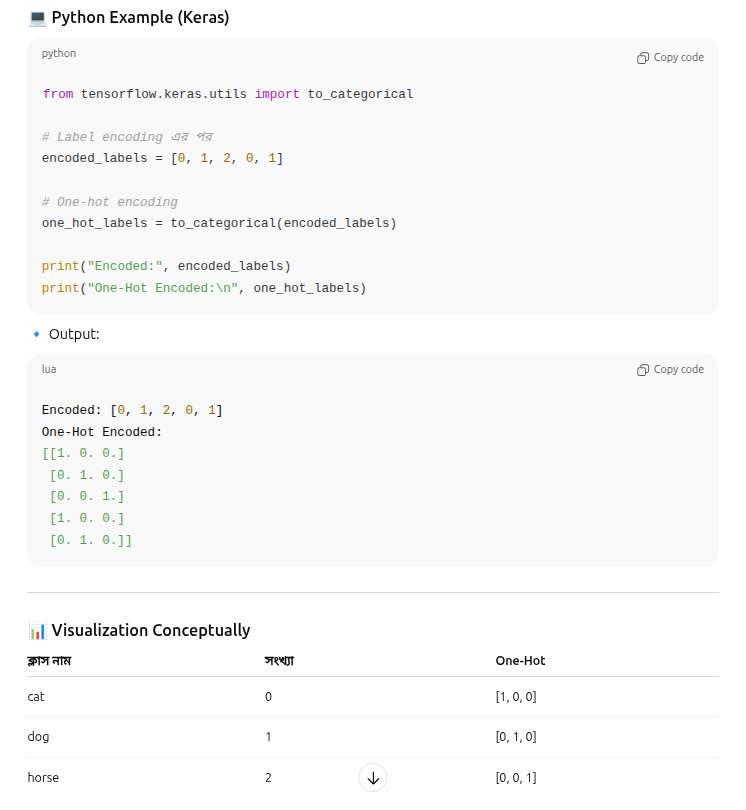

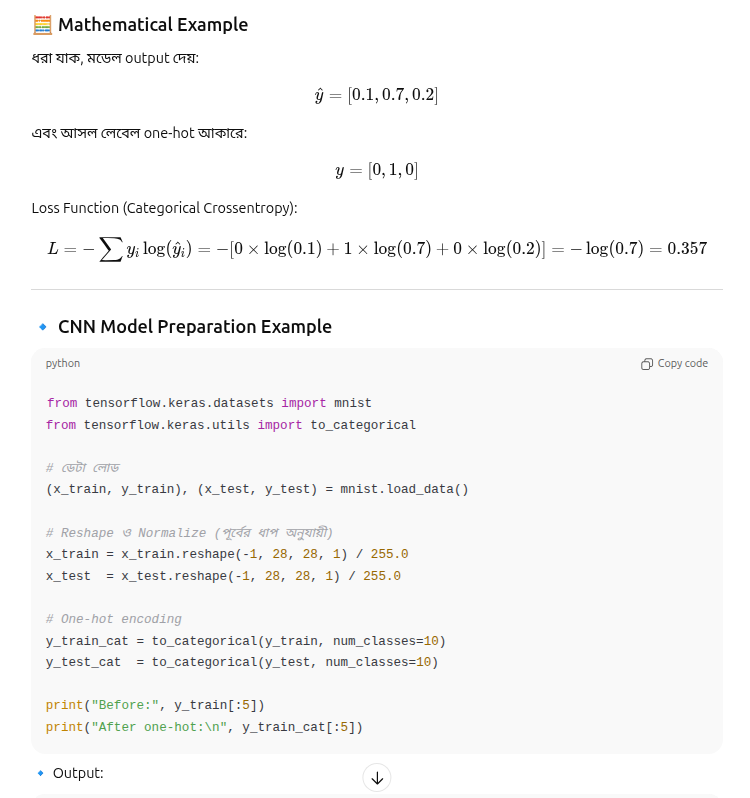

In [17]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# ডেটা লোড
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape ও Normalize (পূর্বের ধাপ অনুযায়ী)
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test  = x_test.reshape(-1, 28, 28, 1) / 255.0

# One-hot encoding
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test, num_classes=10)

print("Before:", y_train[:5])
print("After one-hot:\n", y_train_cat[:5])

Before: [5 0 4 1 9]
After one-hot:
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


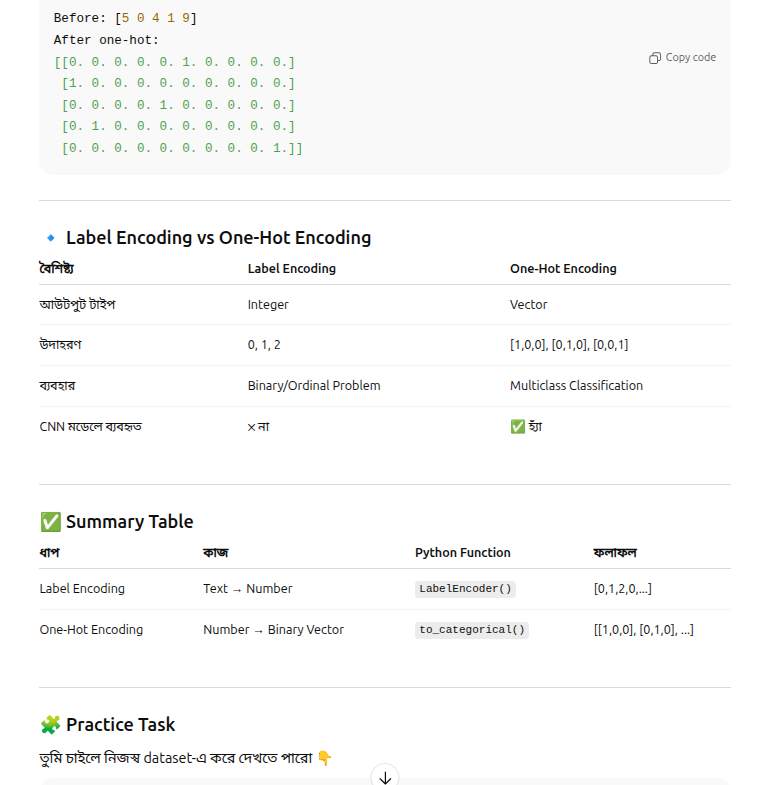

In [18]:
import os
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Folder name = class name ধরে নেওয়া
dataset_dir = "dataset/train"
class_names = os.listdir(dataset_dir)

# Label Encoding
le = LabelEncoder()
class_labels = le.fit_transform(class_names)

# One-Hot Encoding
one_hot_labels = to_categorical(class_labels)

print("Classes:", class_names)
print("Encoded:", class_labels)
print("One-Hot:\n", one_hot_labels)

Classes: ['trent', 'costa', 'fernandes', 'dias', 'kohli', 'cancelo', 'pickford', 'sinner', 'brozovic', 'vitinha', 'deligt', 'messi', 'bale', 'pepe', 'saka', 'marcelo', 'ozil', 'bruyne', 'casimiro', 'mbappe', 'ramos', 'rodriguez', 'shelton', 'ronaldo', 'mendes', 'mane', 'haaland', 'gordon', 'cummins', 'aqidi']
Encoded: [28  6 10  9 13  4 21 27  2 29  8 18  1 20 25 15 19  3  5 16 22 23 26 24
 17 14 12 11  7  0]
One-Hot:
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.]
 [0. 0.